# Research Question Definition

## Complete Question
Dropout regularization consists of dropping selected neurons (in the hidden layers and input layer) during various stages of training a neural network. This has the effect of forcing more of the network to be active, and can improve accuracy, reduce overfitting, and so on. For CNNs, a somewhat analogous technique is cutout regularization, where selected parts of the image are blocked out, forcing the model to learn based on parts of the image that might otherwise be ignored. Typically, dropouts and cutouts are selected at random. However, a recent paper considered a clever use of heatmaps (based on Class Activation Mappings, or CAM) to determine which areas of an image a CNN is focusing most attention on, and then applied cutouts to those “hot” areas. This is a more intelligent and focused approach, as compared
to random cutouts, and it should be more effective in the sense of reducing training time and potentially improving the results. For a project, we would want to implement such a heatmap technique, and conduct extensive experiments to determine how models trained based on “heatmap cutouts” compare to analogous models trained on random cutouts and models trained with no cutouts. These experiments could involve any type of dataset (there are many good malware datasets that would be appropriate, for example).

## Summary
- Dropout regularization randomly drops neurons to prevent overtraining
- CNN equivalent is cutout regularization
    - CNNs are best for images
- New technique: instead of cutout being random, we can use heatmaps
    - Find which areas of an image the CNN is focusing on, and cut those out

# Literature Review
Reference paper: https://www.sciencedirect.com/science/article/pii/S2214212625001000 
## Datasets 
- MalImg
- Big2015
- VX-Zoo
## Background 
- Malware visualization converts malware binaries into images so CNNs can classify them
- This approach achieves high accuracy, but has poor replicability
- CNN classifiers are also black-box classifiers, so low explicability
- A saliency map is a visualization that shows which parts of an input most influenced a model’s prediction
- Saliency maps can highlight image regions that influence prediction, but their interpretation is subjective and not standardized
## Methodology
1. Datasets
    - The authors use three datasets to ensure robustness and generalization
        - MalImg and Big2015 as standard benchmark datasets
        - VX-Zoo for generalizing to newer malware 
2. CNN Models
    - The authors re-implemented 6 CNNs from cited papers
    - Missing or unclear hyperparameters in original papers are inferred or tuned empirically
        - Custom CNN
        - VGG16
        - ResNet50
        - IMCFN (modified VGG16)
        - DenseNet121
        - EfficientNet-B0
3. Model Interpretation
    - Explainability is studied using Class Activation Maps (CAMs)
        - GradCAM: standard gradient-weighted saliency maps
        - HiResCAM: higher-resolution variant that preserves feature importance
    - Sample-level heatmaps are generated and aggregated into cumulative heatmaps per malware family
    - Analyzed whether different CNNs focus on different image regions when classifying the same family or not
4. Comparisons
    - To compare explainability across models, the authors use:
        - Structural Similarity Index (SSIM) to measure similarity between cumulative heatmaps
        - Cumulative-SSIM (new metric) to compare how consistently different CNNs explain the same malware family
    - This allows ranking CNNs not just by accuracy, but by stability and consistency of explanations
5. Masking Strategy (Performance)
    - Explainability is actively exploited via a masking technique
    - The heatmaps of two CNNs are merged via logical OR
    - Regions deemed **unimportant** (below a threshold) are masked out
    - The classifier is forced to focus on relevant regions only
6. ViT as a Validation Classifier
    - The masked datasets are used to train a ViT to avoid CNNs explaining CNNs
    - Improved ViT performance shows that explainability insights are transferable

# Project Outline
## Datasets
- CIFAR-100 for classification, many classes
- CIFAR-10 as a sanity check dataset

## Methodology
1. Datasets
    - Could use multiple datasets for robustness and generalization
2. CNN Models
    - Five or six standard CNN models for comparability, including pretrained models
        - ResNet-18
        - WideResNet-28-10
        - DenseNet-121
        - EfficientNet-B0
        - ConvNeXt-Tiny
    - Models are trained using identical hyperparameters across all conditions in order to isolate the effect of the masking
    - A warm-up phase with no masking to set the saliency estimates
3. Model Interpretation
    - Use CAM and HiResCAM during training to guide the masking decisions
4. Masking Strategies
    - No masking and random masking (control)
    - Denoising with CAMs
    - Regions with low saliency are masked, similar to referenced paper
    - Regularization with CAMs (similar to dropout)
    - Regions with high saliency are masked so model focuses on ignored features
    - All masking strategies:
        - Mask the same fraction of image area
        - Use identical mask shapes and fill values
        - Are evaluated across multiple masking strengths (e.g., 10%, 20%)
5. Metrics
    - Models could be compared using
        - Accuracy
        - Learning curves and convergence speed
        - Steps or epochs required to reach a target performance
    - Robustness can be tested using
        - Multiple random seeds
        - Mean plus/minus standard deviation 
6. Research Questions
    - A direct empirical comparison between:
        - Saliency-guided masking of unimportant regions
        - Saliency-guided masking of important regions
        - Random masking
        - No masking
    - Evidence that CAMs can be used as training signals
    - Insights for when the CAM-guided regularization could improve generalization


# Experimental Data
## Step 1: Data load
### Setup: imports for loading CIFAR-100 data

The  **CIFAR-100** dataset is stored locally in `cifar-100-python/`.
This first cell
- imports the libraries needed to load the data
- implements a helper function to read the batch files, which are pickled Python dictionaries, into memory

In [3]:
import pickle
from matplotlib import pyplot as plt 
import numpy as np
import os
seed = 42
np.random.seed(seed)

PATH_100 = "../cifar-100-python/"

def unpickle(path):
    with open(path, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
    return data_dict

### Load and preprocess CIFAR-100
This cell defines `cifar_100(normalize=True)`, a data loading function that returns:
- `train_set`: `(X_train, y_train_fine, y_train_coarse)`
- `test_set`: `(X_test, y_test_fine, y_test_coarse)`
- `meta_set`: `(fine_names, coarse_names)`

Key steps:
- Reads the `train`, `test`, and `meta` files using the `unpickle()` helper
- Reshapes the raw image bytes into arrays of shape **(N, 32, 32, 3)** (height, width, RGB channels)
- Verifies the expected dataset sizes (**50,000** training images and **10,000** test images)
- Converts images to `float32`, and optionally normalizes pixel values
- Extracts both **fine** (100 classes) and **coarse** (20 superclasses) labels
- Extracts readable label names from metadata

This cell calls `cifar_100()` and unpacks the returned tuples into variables used throughout the notebook

In [6]:
def cifar_100(normalize=True):
    train = unpickle(os.path.join(PATH_100, "train"))
    test = unpickle(os.path.join(PATH_100, "test"))
    meta = unpickle(os.path.join(PATH_100, "meta"))

    # (batch size, height, width, color channels)
    X_train = train[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1) 
    X_test = test[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    # verify data loaded as expected
    s1, s2 = 50000, 10000
    assert X_train.shape[0] == s1, f"{s1} images expected but found {X_train.shape[0]}"
    assert X_test.shape[0] == s2, f"{s2} images expected but found {X_test.shape[0]}"

    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)

    if normalize:
        X_train = X_train / 255.0
        X_test  = X_test / 255.0

    y_train_fine = np.array(train[b"fine_labels"])
    y_train_coarse = np.array(train[b"coarse_labels"])
    y_test_fine = np.array(test[b"fine_labels"])
    y_test_coarse = np.array(test[b"coarse_labels"])

    fine_names = [n.decode("utf-8") for n in meta[b"fine_label_names"]]
    coarse_names = [n.decode("utf-8") for n in meta[b"coarse_label_names"]]

    train_set = (X_train, y_train_fine, y_train_coarse)
    test_set = (X_test, y_test_fine, y_test_coarse)
    meta_set = (fine_names, coarse_names)
    return train_set, test_set, meta_set


train, test, meta = cifar_100()
X_train, y_train_fine, y_train_coarse = train
X_test, y_test_fine, y_test_coarse = test
fine_names, coarse_names = meta

### Display a random or chosen image example
This cell defines `display_image(data, i=None)`, a helper for quickly inspecting images and their labels.

- `data` is a tuple like the ones returned from `cifar_100()` (e.g., `train` or `test`), containing:
    - `X`: image array of shape `(N, 32, 32, 3)`
    - `y_fine`: fine-grained class IDs (0–99)
    - `y_coarse`: coarse superclass IDs (0–19)

If `i` is not provided, the function picks a random index and prints which image is shown. It then displays the image and sets the plot title to the human-readable fine and coarse class names.

In [3]:
def display_image(data, i=None):
    X, y_fine, y_coarse = data
    if i is None:
        i = np.random.randint(0, len(X))
        print(f"Displaying image {i}")

    img = X[i]
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")

    f = int(y_fine[i])
    c = int(y_coarse[i])
    fine_name = fine_names[f]
    coarse_name = coarse_names[c]
    title = f"Fine name: {fine_name}, " + f"Coarse name: {coarse_name}"
    plt.title(title)

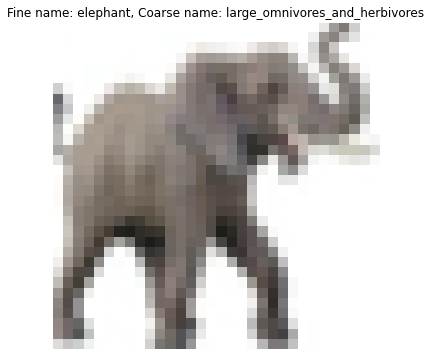

In [4]:
display_image(train, 9)

Displaying image 15795


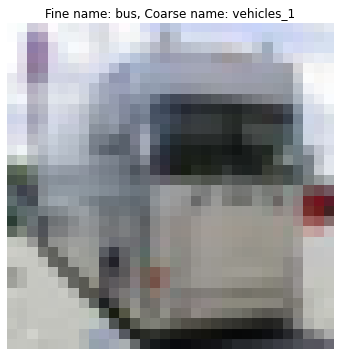

In [5]:
display_image(train)

## Step 2: 

In [4]:
import os, random, numpy as np, torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [16]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD  = (0.2675, 0.2565, 0.2761)

train_tfms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

data_root = "./data"  # change if you want
train_ds = datasets.CIFAR100(root=data_root, train=True, download=True, transform=train_tfms)
test_ds  = datasets.CIFAR100(root=data_root, train=False, download=True, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 169M/169M [00:05<00:00, 30.6MB/s] 


In [17]:
def cifar_resnet18(num_classes=100):
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = cifar_resnet18(100).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)  # epochs


In [18]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * y.size(0)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

In [ ]:
best_acc = 0.0
epochs = 100
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    te_loss, te_acc = evaluate(model, test_loader)
    scheduler.step()

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({"model": model.state_dict(), "acc": best_acc, "epoch": epoch}, "resnet18_cifar100_baseline.pt")

    print(f"epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | test loss {te_loss:.4f} acc {te_acc:.4f} | best {best_acc:.4f}")

c:\Python39\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
